**1. K-Means Clustering and Visualization (Blobs)**

This section generates a synthetic 2D dataset consisting of 1,000 samples grouped into four distinct isotropic Gaussian clusters (blobs). It then initializes and fits a standard K-Means clustering algorithm (k=4) to partition the unlabeled points, subsequently measuring the clustering quality using Inertia (within-cluster sum of squares) and the Silhouette Score. Finally, it generates a side-by-side visual comparison displaying the raw, unlabeled data next to the freshly assigned cluster groupings and their calculated centroids.

Inertia: 2797.9808938074557
Silhouette: 0.7501155415904456


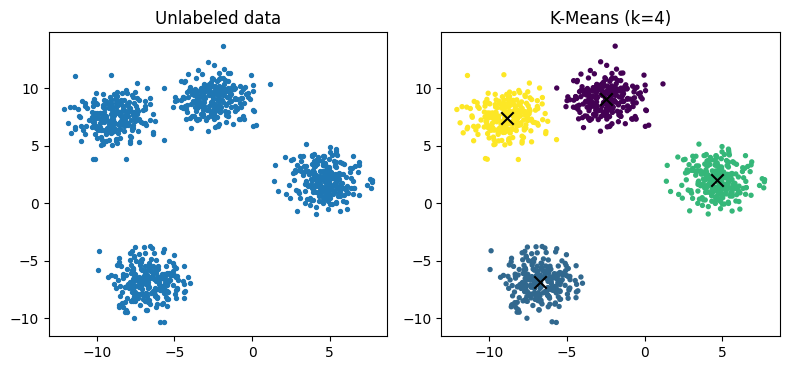

In [5]:
# Import necessary modules for dataset generation, clustering, metrics, and visualization
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# 1. Generate a synthetic 2D dataset with 1000 samples distributed across 4 distinct clusters
X, _ = make_blobs(n_samples=1000, centers=4, cluster_std=1.2, random_state=42)

# 2. Initialize the K-Means algorithm configured for 4 clusters
# n_init=10 ensures the algorithm runs 10 times with different centroid seeds to choose the best outcome
km = KMeans(n_clusters=4, n_init=10, random_state=42)

# 3. Fit the model to the data and predict the cluster assignments for each data point
labels = km.fit_predict(X)

# 4. Calculate and print performance metrics: Inertia (lower is better) and Silhouette Score (closer to 1 is better)
print("Inertia:", km.inertia_)
print("Silhouette:", silhouette_score(X, labels))

# 5. Set up a side-by-side plotting area (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))

# Plot the raw, unsegmented data points on the left subplot
ax[0].scatter(X[:, 0], X[:, 1], s=8)
ax[0].set_title("Unlabeled data")

# Plot the segmented data points colored by their predicted cluster label on the right subplot
ax[1].scatter(X[:, 0], X[:, 1], c=labels, s=8)

# Mark the final calculated cluster centers (centroids) with an 'X'
ax[1].scatter(
    km.cluster_centers_[:, 0],
    km.cluster_centers_[:, 1],
    marker="x",
    s=80,
    color="black",
)
ax[1].set_title("K-Means (k=4)")

# Adjust layout spacing and display the final plots
plt.tight_layout()
plt.show()

**2. Choosing k: Elbow Plot and Silhouette Analysis**

This section sweeps through a range of cluster counts (k from 2 to 9) using K-Means to find the optimal number of clusters for the dataset. It calculates and prints the performance metrics (Inertia and Silhouette Score) for each configuration, and then generates two visualizations: an Elbow Plot (tracking how tightly grouped the clusters are) and a side-by-side scatter plot comparison for k=3, 4, and 6 that highlights the calculated centroids and individual silhouette values.

[(2, 32452.501498713027, np.float64(0.576)), (3, 8184.811919679527, np.float64(0.729)), (4, 2797.9808938074557, np.float64(0.75)), (5, 2537.8998075399086, np.float64(0.619)), (6, 2282.107660515619, np.float64(0.506)), (7, 2036.3055850910403, np.float64(0.406)), (8, 1810.1210787540433, np.float64(0.328)), (9, 1684.877243887097, np.float64(0.326))]


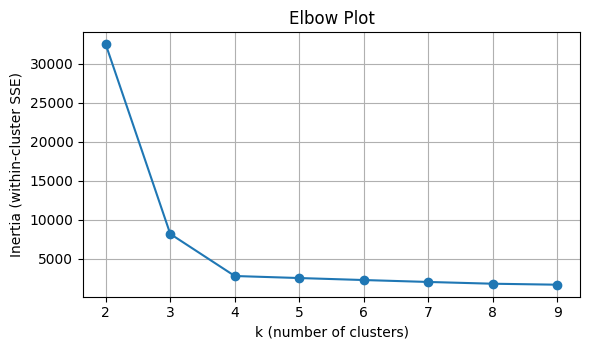

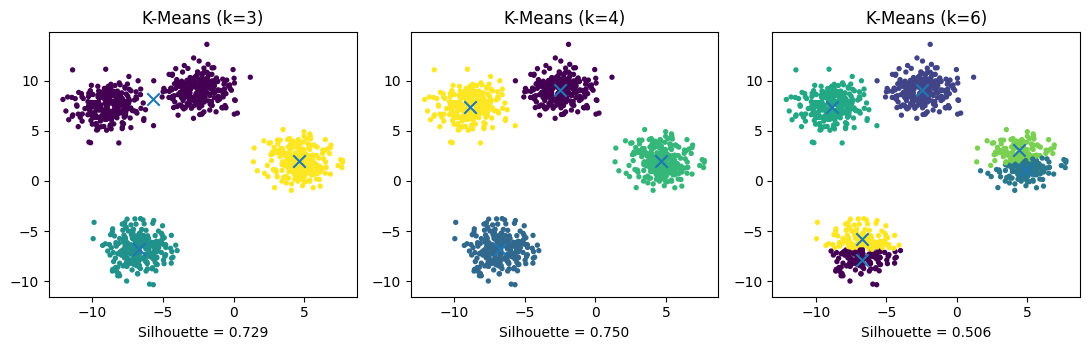

In [6]:
# Import necessary modules for mathematical operations, visualization, and clustering metrics
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Initialize empty lists to store metrics, and define the range of k values to evaluate
inertias, sils, ks = [], [], range(2, 10)

# 2. Iterate through each k value to fit the K-Means model and record performance
for k in ks:
    # Fit the K-Means algorithm for the current number of clusters
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)

    # Append the resulting inertia (total within-cluster sum of squares)
    inertias.append(km.inertia_)

    # Append the calculated silhouette score (evaluates cluster separation and density)
    sils.append(silhouette_score(X, km.labels_))

# 3. Print a structured summary list pairing each k value with its inertia and rounded silhouette score
print(list(zip(ks, inertias, np.round(sils, 3))))

# 4. Generate Figure 1: The Elbow Plot (Inertia vs. k)
plt.figure(figsize=(6, 3.6))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Generate Figure 2: Side-by-side scatter plot comparisons for specific k values (3, 4, and 6)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))

for idx, k in enumerate([3, 4, 6]):
    # Fit a new K-Means model for the current specific k value
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)

    # Calculate its overall silhouette score
    s = silhouette_score(X, km.labels_)

    # Plot the data points colored according to their predicted cluster assignments
    ax[idx].scatter(X[:, 0], X[:, 1], c=km.labels_, s=8)

    # Superimpose the cluster centroids onto the plot as black/standard 'X' markers
    ax[idx].scatter(
        km.cluster_centers_[:, 0],
        km.cluster_centers_[:, 1],
        marker="x",
        s=80,
    )

    # Set descriptive titles and apply the calculated silhouette score as the x-axis label below each plot
    ax[idx].set_title(f"K-Means (k={k})")
    ax[idx].set_xlabel(f"Silhouette = {s:.3f}")

# Finalize the layout constraints and display the subplots
plt.tight_layout()
plt.show()

**3. Initialisation Matters: K-Means++ vs Random**

This section demonstrates how the choice of initial centroid locations impacts the K-Means algorithm. It runs the clustering process twice on the same dataset: first using a single random initialization (which is faster but prone to getting stuck in poor local minima), and second using the optimized K-Means++ initialization protocol across multiple restarts. The code calculates the final inertia for both runs and displays a side-by-side visual comparison showing how the resulting cluster boundaries and final centroid locations differ between the two initialization methods.

Random init inertia: 5135.620592280382
K-means++ inertia: 934.2439192970836


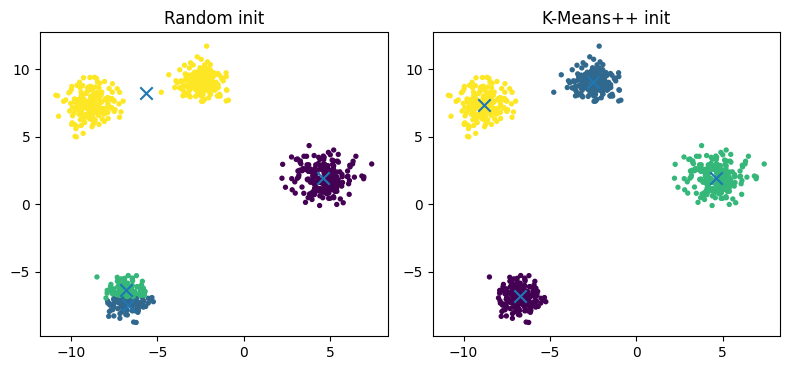

Random init iterations: 7
K-means++ iterations: 2


In [15]:
# Import necessary modules for visualization and clustering
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Fit a K-Means model using a single, completely random initialization (n_init=1)
km_rand = KMeans(
    n_clusters=4, init="random", n_init=1, random_state=42
).fit(X)

# 2. Fit a K-Means model using the smart k-means++ initialization with 10 restarts (n_init=10)
km_pp = KMeans(
    n_clusters=4, init="k-means++", n_init=10, random_state=42
).fit(X)

# 3. Print the final total within-cluster sum of squares (inertia) for both methods to compare quality
print("Random init inertia:", km_rand.inertia_)
print("K-means++ inertia:", km_pp.inertia_)

# 4. Set up a side-by-side plotting area (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))

# Plot the cluster results and centroids obtained from the random initialization
ax[0].scatter(X[:, 0], X[:, 1], c=km_rand.labels_, s=8)
ax[0].scatter(
    km_rand.cluster_centers_[:, 0],
    km_rand.cluster_centers_[:, 1],
    marker="x",
    s=80,
)
ax[0].set_title("Random init")

# Plot the cluster results and centroids obtained from the K-Means++ initialization
ax[1].scatter(X[:, 0], X[:, 1], c=km_pp.labels_, s=8)
ax[1].scatter(
    km_pp.cluster_centers_[:, 0],
    km_pp.cluster_centers_[:, 1],
    marker="x",
    s=80,
)
ax[1].set_title("K-Means++ init")

# Clean up layout spacing and render the visual comparison
plt.tight_layout()
plt.show()
print("Random init iterations:", km_rand.n_iter_)
print("K-means++ iterations:", km_pp.n_iter_)


**4. DBSCAN vs K-Means (Non-Spherical Clusters)**


This section demonstrates a scenario where the K-Means algorithm struggles because it assumes clusters are spherical and equal in size. It introduces DBSCAN (Density-Based Spatial Clustering of Applications with Noise), which group points based on how closely packed they are. This allows DBSCAN to easily identify arbitrary shapes and automatically flag isolated, low-density points as noise.

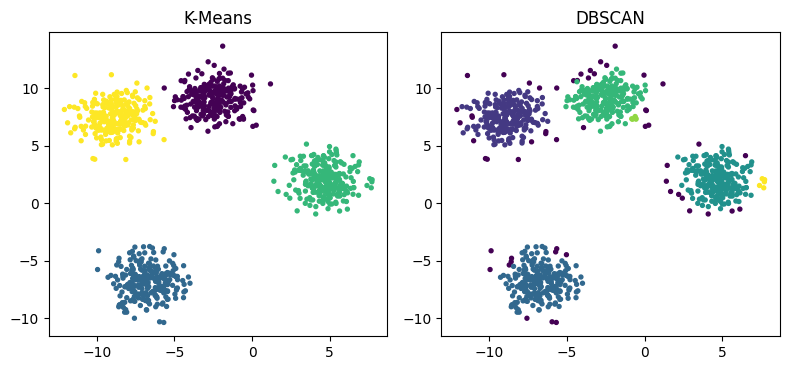

In [8]:
# Import necessary modules for visualization and clustering
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans

# 1. Fit a K-Means model to the dataset using 4 clusters
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X)

# 2. Fit a DBSCAN model to the dataset
# eps sets the maximum distance between two samples to be considered in the same neighborhood
# min_samples sets the number of samples in a neighborhood for a point to be considered a core point
db = DBSCAN(eps=0.6, min_samples=5).fit(X)

# 3. Set up a side-by-side plotting area (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))

# Plot the K-Means results where it attempts to force spherical boundaries
ax[0].scatter(X[:, 0], X[:, 1], c=km.labels_, s=8)
ax[0].set_title("K-Means")

# Plot the DBSCAN results which successfully identifies density-based shapes
# Any points assigned a label of -1 by DBSCAN represent identified noise/outliers
ax[1].scatter(X[:, 0], X[:, 1], c=db.labels_, s=8)
ax[1].set_title("DBSCAN")

# Adjust spacing cleanly and display the comparison
plt.tight_layout()
plt.show()

**5. Hierarchical Clustering and Dendrograms**

This section demonstrates Hierarchical (Agglomerative) Clustering, which builds a tree-like structure of clusters by progressively merging nearby data points. It uses a Ward-linkage method to minimize variance during merges and visualizes this step-by-step history using a tree diagram called a dendrogram on a subset of the data. Finally, it runs the full clustering algorithm for 4 clusters and plots a side-by-side comparison of the raw data against the final hierarchical groupings.

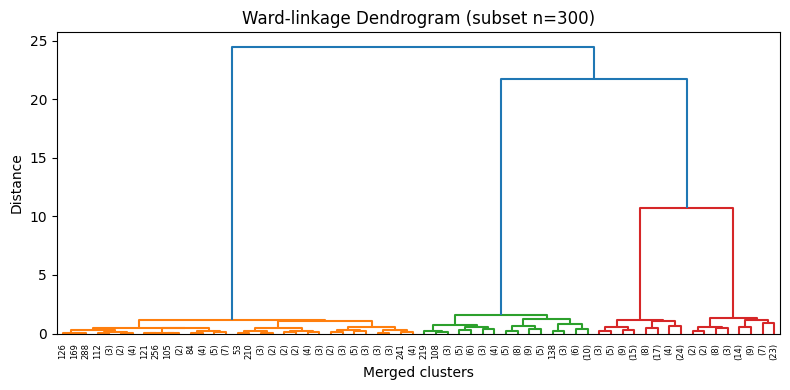

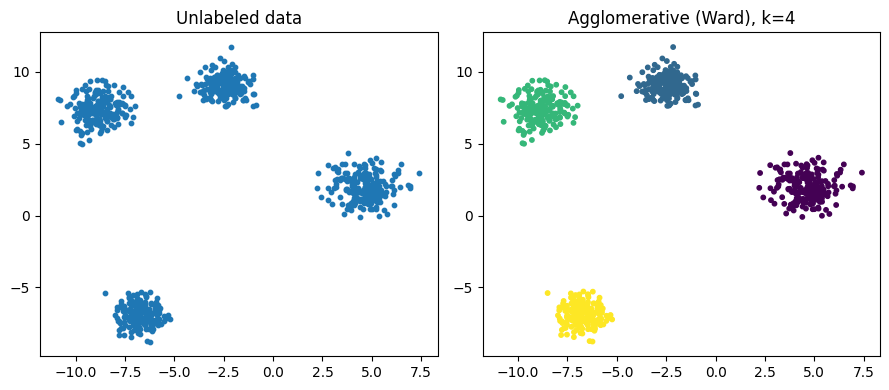

In [9]:
# Import necessary modules for data generation, scaling, hierarchical clustering, and plotting
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

# 1. Generate a synthetic dataset with 800 samples spread across 4 clusters with varying standard deviations
X, y_true = make_blobs(
    n_samples=800,
    centers=4,
    cluster_std=[0.70, 0.90, 0.65, 0.80],
    random_state=42,
)

# Scale features so they have a mean of 0 and variance of 1 (essential since Ward linkage relies on Euclidean distances)
Xs = StandardScaler().fit_transform(X)

# 2. Compute the hierarchical linkage matrix using a subset of 300 samples for better dendrogram readability
Z = linkage(Xs[:300], method="ward")

# Create and display the Dendrogram plot showing how smaller clusters merge into larger ones
plt.figure(figsize=(8, 4))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Ward-linkage Dendrogram (subset n=300)")
plt.xlabel("Merged clusters")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# 3. Initialize and fit the full Agglomerative Clustering model configured to find 4 final clusters
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels = agg.fit_predict(Xs)

# 4. Set up a side-by-side plotting area (1 row, 2 columns) to evaluate the clustering results
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

# Plot the raw unsegmented data on the left subplot
ax[0].scatter(X[:, 0], X[:, 1], s=10)
ax[0].set_title("Unlabeled data")

# Plot the data colored by their hierarchical cluster assignments on the right subplot
ax[1].scatter(X[:, 0], X[:, 1], c=labels, s=10)
ax[1].set_title("Agglomerative (Ward), k=4")

# Adjust layout constraints cleanly and display the final plots
plt.tight_layout()
plt.show()

**6. Image Segmentation with K-Means (Color Quantisation)**


This section demonstrates color quantization by treating every individual pixel in an image as a 3D data point (representing Red, Green, and Blue color channels). It uses K-Means to group similar colors together into a specified number of clusters (k = 8, 4, and 2), replaces each pixel's original color with its nearest cluster center color, and displays a 2x2 grid comparison of the original image against the compressed versions.

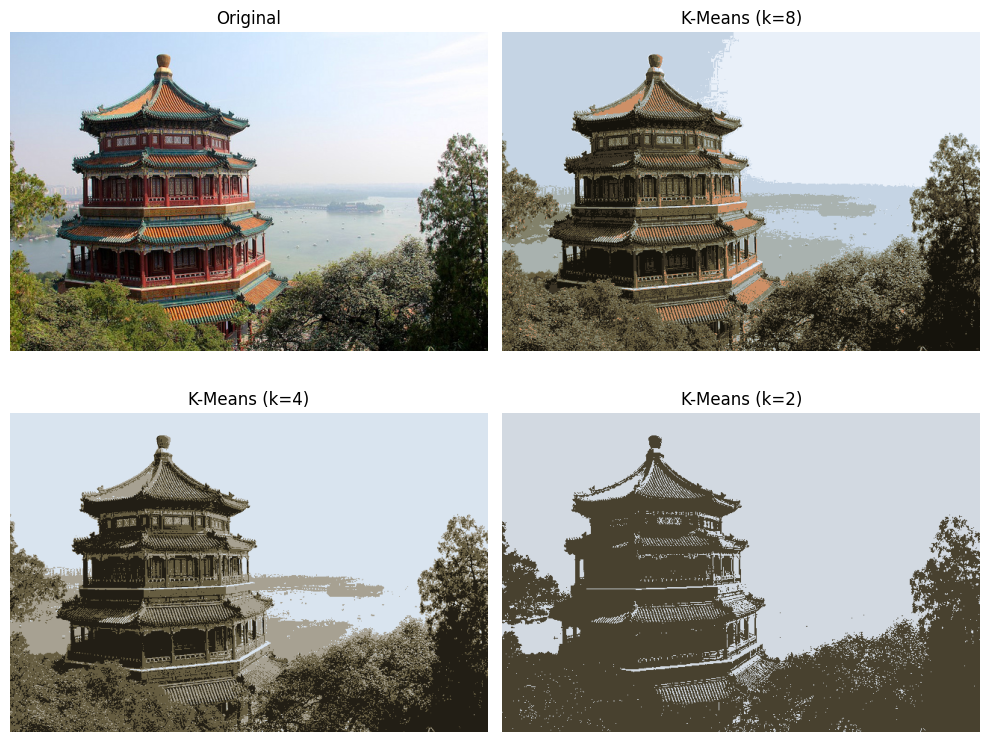

In [14]:
# Import necessary modules for visualization, matrix manipulation, clustering, and sample image data
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import load_sample_image

# 1. Load a built-in sample image from scikit-learn (no external downloads required)
img = load_sample_image("china.jpg")  # Shape: (H, W, 3), uint8

# 2. Prepare data for K-Means by flattening the 2D image grid into a long list of RGB pixels
X_img = img.reshape(-1, 3)

# 3. Run K-Means for 8 colors, map pixels to centroids, and reconstruct the image shape
km_k8 = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X_img)
seg_k8 = (
    km_k8.cluster_centers_[km_k8.labels_].reshape(img.shape).astype(np.uint8)
)

# 4. Run K-Means for 4 colors, map pixels to centroids, and reconstruct the image shape
km_k4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_img)
seg_k4 = (
    km_k4.cluster_centers_[km_k4.labels_].reshape(img.shape).astype(np.uint8)
)

# 5. Run K-Means for 2 colors, map pixels to centroids, and reconstruct the image shape
km_k2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_img)
seg_k2 = (
    km_k2.cluster_centers_[km_k2.labels_].reshape(img.shape).astype(np.uint8)
)

# 6. Set up a 2x2 grid layout to visually compare the original image against the 3 quantized results
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Display the original unmodified image
axes[0, 0].imshow(img)
axes[0, 0].axis("off")
axes[0, 0].set_title("Original")

# Display the compressed image containing only 8 colors
axes[0, 1].imshow(seg_k8)
axes[0, 1].axis("off")
axes[0, 1].set_title("K-Means (k=8)")

# Display the compressed image containing only 4 colors
axes[1, 0].imshow(seg_k4)
axes[1, 0].axis("off")
axes[1, 0].set_title("K-Means (k=4)")

# Display the compressed image containing only 2 colors (highest compression)
axes[1, 1].imshow(seg_k2)
axes[1, 1].axis("off")
axes[1, 1].set_title("K-Means (k=2)")

# Clean up layout spacing and render the grid
plt.tight_layout()
plt.show()

**7. GMM: Soft Clustering and Anomaly Scoring**

This section demonstrates Gaussian Mixture Models (GMM), which perform soft clustering by calculating the probability that each data point belongs to a specific cluster, rather than assigning a hard label. It adds random uniform outliers to a standard dataset and uses the model's calculated sample log-likelihood scores to flag the bottom 2% of data points as anomalies. The results are visualized in a side-by-side comparison marking the raw data against the GMM clusters with highlighted anomalies.

Anomalies detected: 25


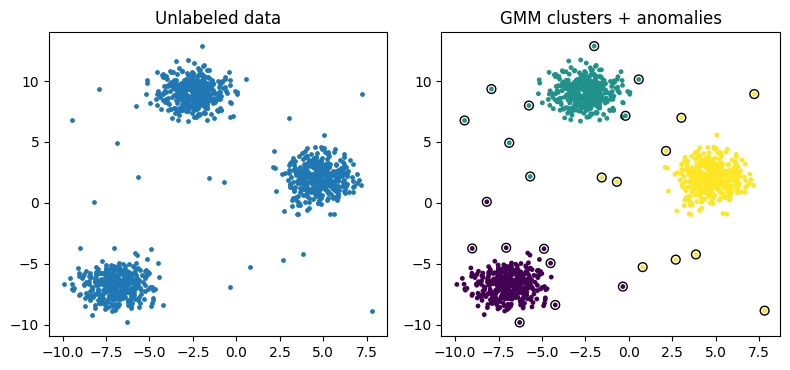

In [ ]:
# Import necessary modules for dataset generation, mathematical operations, visualization, and mixture modeling
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

# 1. Generate a synthetic dataset with 1200 samples grouped into 3 standard clusters
Xg, _ = make_blobs(n_samples=1200, centers=3, random_state=42, cluster_std=1.0)

# 2. Introduce 20 random uniform noise points (outliers) into the dataset
Xg = np.vstack(
    [Xg, np.random.uniform(low=-10, high=10, size=(20, Xg.shape[1]))]
)

# 3. Fit a Gaussian Mixture Model configured for 3 components using full covariance matrices
gmm = GaussianMixture(
    n_components=3, covariance_type="full", random_state=42
).fit(Xg)

# 4. Compute the log-likelihood score for each sample to measure how well it fits the distribution
logp = gmm.score_samples(Xg)

# 5. Define an anomaly threshold at the bottom 2% percentile of the log-likelihood scores
threshold = np.percentile(logp, 2.0)

# Create a boolean mask identifying points that fall below the determined anomaly threshold
anomalies = logp < threshold
print("Anomalies detected:", anomalies.sum())

# 6. Set up a side-by-side plotting area (1 row, 2 columns) to evaluate the model's performance
fig, ax = plt.subplots(1, 2, figsize=(8, 3.8))

# Plot the raw, unsegmented data points including outliers on the left subplot
ax[0].scatter(Xg[:, 0], Xg[:, 1], s=6)
ax[0].set_title("Unlabeled data")

# Plot the points colored by their predicted GMM cluster assignment on the right subplot
ax[1].scatter(Xg[:, 0], Xg[:, 1], c=gmm.predict(Xg), s=6)

# Superimpose empty black circle borders around the points flagged as anomalies
ax[1].scatter(
    Xg[anomalies, 0],
    Xg[anomalies, 1],
    facecolors="none",
    edgecolors="k",
    s=40,
)
ax[1].set_title("GMM clusters + anomalies")

# Clean up layout spacing constraints and render the final plots
plt.tight_layout()
plt.show()